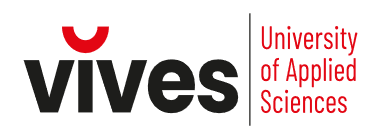<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **LINEAR CLASSIFICATION: EXERCISES**

## Spam or ham?

- Read file `'spam_dataset.csv'`. The dataset contains information about 20 emails classifying them as spam or no spam (= ham).
- Train a perceptron and logistic regression model that predicts whether an email is spam or ham based on the number of spam words.
- Evaluate the models. Which one performs best? Why?
- Make a scatter plot of the data and visualize both models by adding the step function and the sigmoid function that fit the data.

### Solution

In [1]:
# Import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron, LogisticRegression

In [4]:
# Generate synthetic data
num_spam_words = np.concatenate([
    np.arange(10),  # Non-spam (0 label)
    np.arange(8, 18)  # Spam (1 label)
])
labels = np.array([0] * 10 + [1] * 10)

df = pd.DataFrame({'num_spam_words': num_spam_words, 'spam': labels})
df.to_csv('spam_dataset.csv', index=False)
df

,num_spam_words,spam
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
5,5,0
6,6,0
7,7,0
8,8,0
9,9,0


In [137]:
# Read dataset from csv-file into dataframe
df = pd.read_csv('spam_dataset.csv')
df.head()

,num_spam_words,spam
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [138]:
# feature and label
X = df[['num_spam_words']]
y = df['spam']

In [139]:
# Train and evaluate models
perceptron = Perceptron(eta0=0.1)
perceptron.fit(X, y)
print(f"Perceptron Accuracy: {perceptron.score(X, y)}")

logreg = LogisticRegression(penalty=None)
logreg.fit(X, y)
print(f"Logistic Regression Accuracy: {logreg.score(X, y)}")

Perceptron Accuracy: 0.8
Logistic Regression Accuracy: 0.9


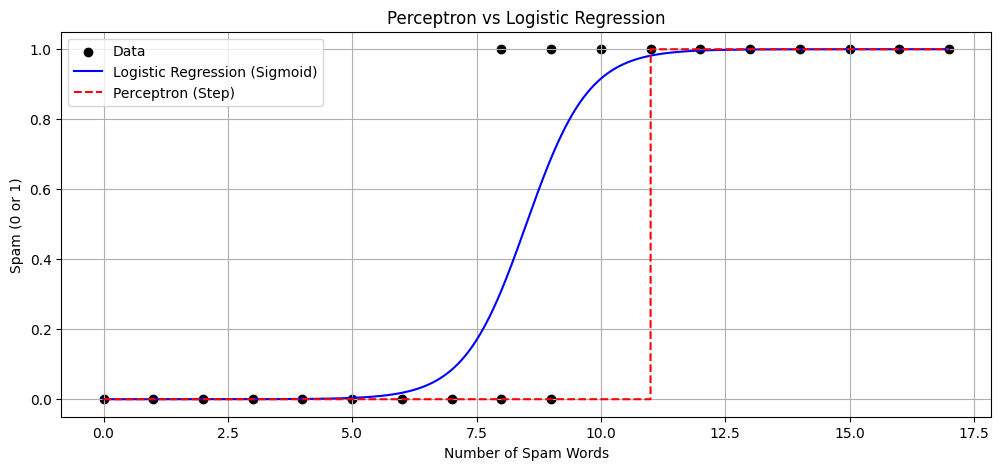

In [140]:
# Visualization
X_range = pd.DataFrame(np.linspace(0, 17, 10000).reshape(-1, 1), columns=['num_spam_words'])
perceptron_preds = perceptron.predict(X_range)
logreg_preds = logreg.predict_proba(X_range)[:, 1]  # predict_proba() to get sigmoid!

# # alternative solution using model parameters
# perceptron_threshold = -perceptron.intercept_[0] / perceptron.coef_[0, 0]  # -b/a
# perceptron_preds = np.where(X_range['num_spam_words'] >= perceptron_threshold, 1, 0)
# a, b = logreg.coef_[0, 0], logreg.intercept_[0]
# logreg_preds = 1 / (1 + np.exp(-a * X_range['num_spam_words'] - b))  # sigmoid

plt.figure(figsize=(12, 5))
plt.scatter(X, y, color='black', label='Data')
plt.plot(X_range, logreg_preds, 'b-', label='Logistic Regression (Sigmoid)')
plt.plot(X_range, perceptron_preds, 'r--', label='Perceptron (Step)')
plt.xlabel('Number of Spam Words')
plt.ylabel('Spam (0 or 1)')
plt.legend()
plt.title('Perceptron vs Logistic Regression')
plt.grid();

## Churn Prediction

Customer churn refers to the percentage of customers who stop using a product or service within a certain period. In dataset `'churn_dataset.csv'`, there are three key variables:

- Monthly Charges ($): This is the amount customers pay monthly for the service, expressed in US dollars.
- Tenure (in months): This indicates how long a customer has been using the service, expressed in months.
- Label "Stayed" or "Churned": This is an indicator showing whether a customer has stayed or stopped using the service.

Perform the following tasks using this dataset:

- Read the file into a Pandas Dataframe.
- Explore the dataset.
- Train a perceptron and logistic regression model.
- Evaluate the models.
- Predict whether a customer with 80$ monthly charges and 35 months of tenure will stay or churn.
- Make a scatter plot of the data points.
- Add the new customer to the plot.
- Visualize the model results by plotting the two decision boundaries.

### Solution

In [67]:
# Import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron, LogisticRegression

In [68]:
from sklearn.datasets import make_blobs

# Generate dataset with overlap
X, y = make_blobs(n_samples=100, centers=2, n_features=2, cluster_std=5, random_state=42)

# Rename features to match churn scenario
monthly_charges = X[:, 0] * 3 + 50   # Scale to represent realistic dollar amounts
tenure_months = np.abs(X[:, 1]) * 2  # Ensure positive tenure
X = np.column_stack((monthly_charges, tenure_months))

# Convert to DataFrame
df = pd.DataFrame(X, columns=['Monthly Charges ($)', 'Tenure (Months)'])
df['Customer'] = y
df['Customer'] = df['Customer'].map({0: 'Stayed', 1: 'Churned'})
df.to_csv('churn_dataset.csv', index=False)
df.head()

,Monthly Charges ($),Tenure (Months),Customer
0,35.284794,16.171982,Stayed
1,80.165405,14.484360,Churned
2,34.306666,19.137798,Stayed
3,76.250539,22.914269,Churned
4,67.331536,17.017767,Churned


In [141]:
# Read dataset into DataFrame
df = pd.read_csv('churn_dataset.csv')
df.head()

,Monthly Charges ($),Tenure (Months),Customer
0,35.284794,16.171982,Stayed
1,80.165405,14.484360,Churned
2,34.306666,19.137798,Stayed
3,76.250539,22.914269,Churned
4,67.331536,17.017767,Churned


In [142]:
# Get info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Monthly Charges ($)  100 non-null    float64
 1   Tenure (Months)      100 non-null    float64
 2   Customer             100 non-null    object 
dtypes: float64(2), object(1)
memory usage: 2.5+ KB


In [143]:
# Calculate summarizing statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly Charges ($),100.0,51.507023,17.581313,3.176231,39.123023,49.180502,64.970919,92.212425
Tenure (Months),100.0,13.250410,8.881080,0.398171,6.218284,11.521522,19.519826,36.551354


In [144]:
# Scale features and encode labels
fac = np.array([100, 40])  # scaling factor
X = df[['Monthly Charges ($)', 'Tenure (Months)']].values / fac
y = (df['Customer'] == 'Churned').astype(int).values

In [147]:
# Train and evaluate models
perceptron = Perceptron(eta0=0.1)
perceptron.fit(X, y)
print(f"Perceptron Accuracy: {perceptron.score(X, y):.2%}")

logreg = LogisticRegression()
logreg.fit(X, y)
print(f"Logistic Regression Accuracy: {logreg.score(X, y):.2%}")

Perceptron Accuracy: 84.00%
Logistic Regression Accuracy: 84.00%


In [148]:
# Predictions for new customer
customer = np.array([[80, 35]])
y_pred_perceptron = perceptron.predict(customer / fac).item()
y_pred_logreg = logreg.predict(customer / fac).item()
print(f"Perceptron Prediction: {'Churned' if y_pred_perceptron else 'Stayed'}")
print(f"Logistic Regression Prediction: {'Churned' if y_pred_logreg else 'Stayed'}")

Perceptron Prediction: Churned
Logistic Regression Prediction: Stayed


In [149]:
# Function to plot decision boundary using model parameters
def plot_decision_boundary(model, fac, color, label):
    w = model.coef_[0]
    b = model.intercept_
    X1 = np.array([0, 1])
    X2 = -(w[0] * X1 + b) / w[1]  # Solve for y in w1*x + w2*y + b = 0
    plt.plot(X1 * fac[0], X2 * fac[1], color, linestyle='dashed', label=label)

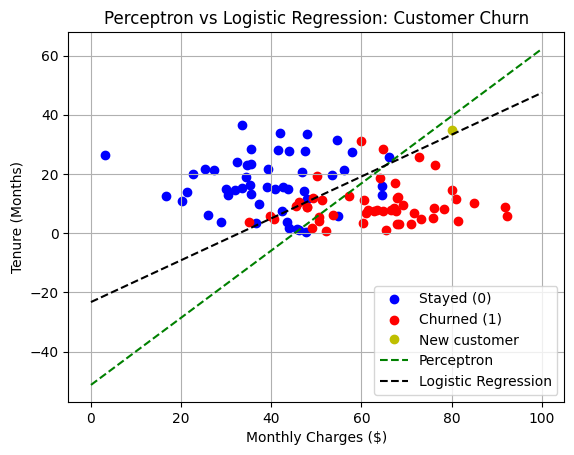

In [150]:
# Plot dataset
plt.scatter(X[y == 0, 0] * fac[0], X[y == 0, 1] * fac[1], color='blue', label='Stayed (0)')
plt.scatter(X[y == 1, 0] * fac[0], X[y == 1, 1] * fac[1], color='red', label='Churned (1)')

# Plot new customer
plt.plot(customer[0, 0], customer[0, 1], 'yo', label='New customer')

# Plot decision boundaries
plot_decision_boundary(perceptron, fac, 'green', 'Perceptron')
plot_decision_boundary(logreg, fac, 'black', 'Logistic Regression')

# Style plot
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Tenure (Months)')
plt.legend()
plt.title('Perceptron vs Logistic Regression: Customer Churn')
plt.grid();

## Logical Gates

Implement logical gates (AND, OR, and XOR) using Perceptron and Logistic Regression. Calculate the accuracy.

Visualize the results using 2 x 3 subplots and add the decision boundaries to the plots.

Why is the XOR gate failing?

### Solution

In [152]:
# Import statements
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron, LogisticRegression

In [162]:
# Define logic gate data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
labels = dict(AND=np.array([0, 0, 0, 1]),
              OR=np.array([0, 1, 1, 1]),
              XOR=np.array([0, 1, 1, 0]))

In [178]:
# Train models and print accuracy
models = {'Perceptron': Perceptron, 'Logistic Regression': LogisticRegression}
results = {}
for name, Model in models.items():
    results[name] = {}
    for gate, y in labels.items():
        results[name][gate] = Model(penalty=None)
        results[name][gate].fit(X, y)
        print(f"{name}: {gate} Accuracy: {results[name][gate].score(X, y):.2%}")
    print()

Perceptron: AND Accuracy: 100.00%
Perceptron: OR Accuracy: 100.00%
Perceptron: XOR Accuracy: 50.00%

Logistic Regression: AND Accuracy: 100.00%
Logistic Regression: OR Accuracy: 100.00%
Logistic Regression: XOR Accuracy: 50.00%



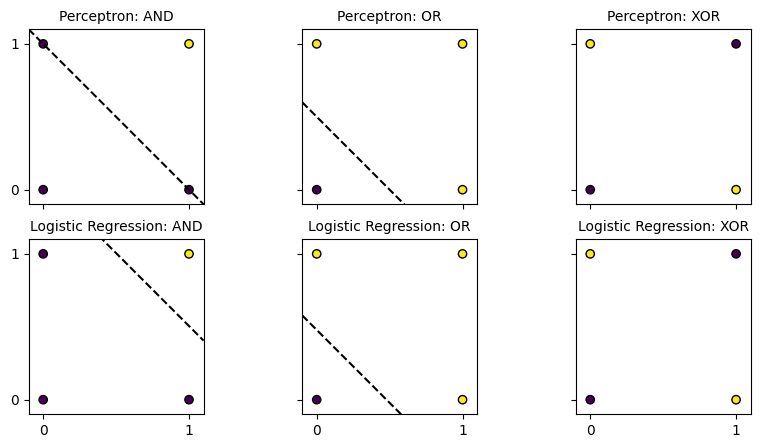

In [177]:
# Plot result using 2 x 3 subplots
fig, axes = plt.subplots(2, 3, figsize=(10, 5), sharex=True, sharey=True)
x_line = np.array([-0.1, 1.1])
for irow, name in enumerate(models.keys()):
    for icol, (gate, y) in enumerate(labels.items()):
        axes[irow, icol].scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
        axes[irow, icol].set_title(f"{name}: {gate}", fontdict={'fontsize': 10})
        # Add decision boundary if not XOR gate
        if gate != 'XOR':
            w, b = results[name][gate].coef_[0], results[name][gate].intercept_
            y_line = -(w[0] * x_line + b) / w[1]
            axes[irow, icol].plot(x_line, y_line, color='black', linestyle='dashed')

# Set limits and ticks for all axes
for ax in axes.flatten():
    ax.set_xlim(x_line)
    ax.set_ylim(x_line)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_aspect('equal')  # Set the aspect ratio to be equal

In [189]:
# The XOR gate is not linearly separable!
# Both models always predict 0 in this case, which gives a 50% accuracy
for name in models.keys():
    print(f"{name}:")
    w = results[name]['XOR'].coef_[0]
    b = results[name]['XOR'].intercept_[0]
    print(f'w = {w} and', f'b = {b}')
    print()

Perceptron:
w = [0. 0.] and b = 0.0

Logistic Regression:
w = [0. 0.] and b = 0.0



## Covid Diagnosis

- Read the file `'covid.csv'` into a Pandas DataFrame.
- Explore and encode the data.
- Train and evaluate a perceptron model and a logistic regression model.
- Use both models to predict whether a patient only coughing and feeling tired must be diagnosed as sick.

### Solution

In [120]:
# Read the dataset into a DataFrame
df = pd.read_csv('covid.csv', sep=';')
df

,Patient (P),Cough (C),Fever (F),Difficulty breathing (B),Tiredness (T),Diagnosis (D)
0,1,NaN,X,X,X,sick
1,2,X,X,NaN,X,sick
2,3,X,NaN,X,X,sick
3,4,X,X,X,NaN,sick
4,5,X,NaN,NaN,X,healthy
5,6,NaN,X,X,NaN,healthy
6,7,NaN,X,NaN,NaN,healthy
7,8,NaN,NaN,NaN,X,healthy


In [121]:
# Get info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Patient (P)               8 non-null      int64 
 1   Cough (C)                 4 non-null      object
 2   Fever (F)                 5 non-null      object
 3   Difficulty breathing (B)  4 non-null      object
 4   Tiredness (T)             5 non-null      object
 5   Diagnosis (D)             8 non-null      object
dtypes: int64(1), object(5)
memory usage: 516.0+ bytes


In [122]:
# Encode the features and the labels
df[df=='X'] = 1
df.fillna(0, inplace=True)
df[df.columns[-1]] = (df[df.columns[-1]] == "sick").astype(int)
df

<ipython-input-122-03915413ba65>:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(0, inplace=True)


,Patient (P),Cough (C),Fever (F),Difficulty breathing (B),Tiredness (T),Diagnosis (D)
0,1,0,1,1,1,1
1,2,1,1,0,1,1
2,3,1,0,1,1,1
3,4,1,1,1,0,1
4,5,1,0,0,1,0
5,6,0,1,1,0,0
6,7,0,1,0,0,0
7,8,0,0,0,1,0


In [123]:
# Assign features and labels to X and y
X = df[df.columns[1:-1]].values
y = df[df.columns[-1]].values

In [124]:
# Train and evaluate models
perceptron = Perceptron(eta0=0.1)
perceptron.fit(X, y)
print(f"Perceptron Accuracy: {perceptron.score(X, y):.2%}")

logreg = LogisticRegression()
logreg.fit(X, y)
print(f"Logistic Regression Accuracy: {logreg.score(X, y):.2%}")

Perceptron Accuracy: 100.00%
Logistic Regression Accuracy: 100.00%


In [125]:
# Prediction for new patient
new_patient = np.array([[1, 0, 0, 1]])
y_pred_perceptron = perceptron.predict(new_patient).item()
y_pred_logreg = logreg.predict(new_patient).item()
print(f"Perceptron Prediction: {'sick' if y_pred_perceptron else 'healthy'}")
print(f"Logistic Regression Prediction: {'sick' if y_pred_logreg else 'healthy'}")

Perceptron Prediction: healthy
Logistic Regression Prediction: healthy


## Online Advertising

Read the dataset `'Social_Network_Ads.csv'` into a Pandas `DataFrame`. You can also find it on [Kaggle](https://www.kaggle.com/datasets/dragonheir/logistic-regression).

Check the data by calculating the summarizing statistics. You can use the `DataFrame` method `describe()` for this. Create a scatter plot where you plot `Age` against `EstimatedSalary`. Color the data points green when `Purchased` is equal to 1, and red when this label is 0.

Apply the perceptron algorithm and logistic regression. Predict the label `Purchased` based on the features `Age` and `EstimatedSalary`. Which of the two models has the highest accuracy?

Plot the dataset again and add the decision boundary from the best model.

Finally, use the model to predict whether the following individuals will make a purchase:

- a 21-year-old woman with a salary of 25,500
- a 38-year-old man with a salary of 110,000
- a 45-year-old man with a salary of 52,000
- a 62-year-old woman with a salary of 120,000

Print your predictions nicely and add the new data points to the scatter plot with the decision boundary to see if your result is correct.

### Solution

In [195]:
# Import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Perceptron, LogisticRegression

In [191]:
# Read dataset
df = pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [192]:
# Summary statistics
df.describe().T  # T = transpose

,count,mean,std,min,25%,50%,75%,max
User ID,400.0,1.569154e+07,71658.321581,15566689.0,15626763.75,15694341.5,15750363.0,15815236.0
Age,400.0,3.765500e+01,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,6.974250e+04,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,3.575000e-01,0.479864,0.0,0.00,0.0,1.0,1.0


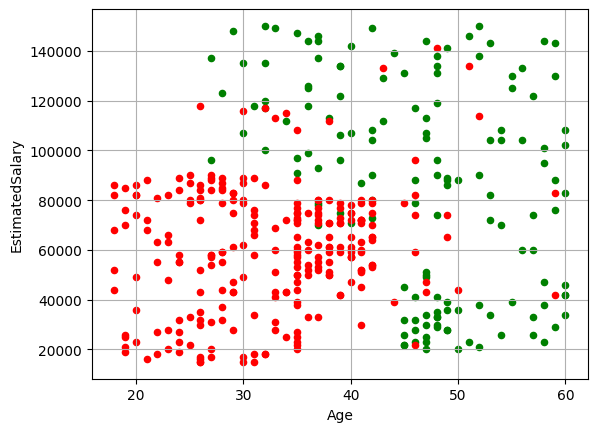

In [193]:
# Scatter plot
fig, ax = plt.subplots()
features = ['Age', 'EstimatedSalary']
label = 'Purchased'
for color, value in dict(g=1, r=0).items():
    df[df[label]==value].plot.scatter(x=features[0], y=features[1], ax=ax, color=color);
plt.grid();

In [194]:
# Features and labels
X = df[features].values.astype(float)
y = df[label].values.astype(int)

In [196]:
# Scale features
scaler = MinMaxScaler()
Xn = scaler.fit_transform(X)

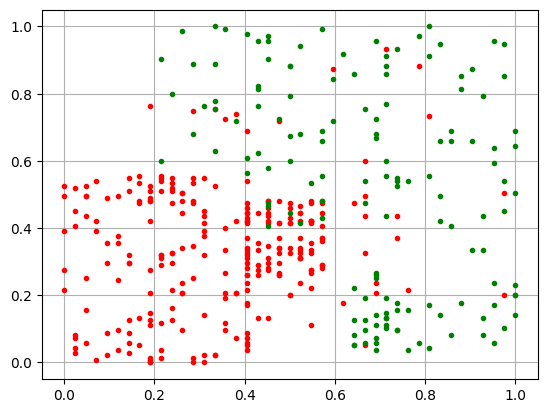

In [207]:
# Check by plotting scaled features

def plot_Xy(X, y):
    plt.plot(X[y==0, 0], X[y==0, 1], 'r.')
    plt.plot(X[y==1, 0], X[y==1, 1], 'g.')
    plt.grid()

plot_Xy(Xn, y)

In [224]:
# Perceptron model
per = Perceptron(eta0=0.01)
per.fit(Xn, y)
per.score(Xn, y)  # accuracy

0.8275

In [205]:
# Logistic regression model
lr = LogisticRegression(penalty=None)
lr.fit(Xn, y)
lr.score(Xn, y)  # accuracy

0.845

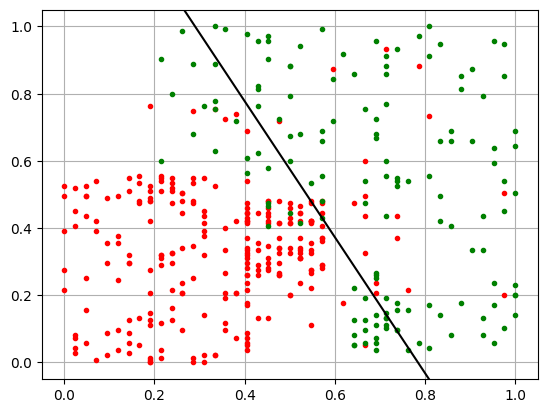

In [221]:
# Logistic regression model performs better

def add_decision_boundary(model):
    xline = np.arange(0, 2)
    w, b = lr.coef_[0], lr.intercept_[0]
    yline = -xline * w[0] / w[1] - b / w[1]
    plt.plot(xline, yline, 'k-');
    plt.xlim((-0.05, 1.05));
    plt.ylim((-0.05, 1.05));

plot_Xy(Xn, y)
add_decision_boundary(lr)

In [222]:
# Predict labels for new data:
# - a 21-year-old woman with a salary of 25,500
# - a 38-year-old man with a salary of 110,000
# - a 45-year-old man with a salary of 52,000
# - a 62-year-old woman with a salary of 120,000

# input (gender is not relevant)
X_new = np.array([[21, 25_500],
                  [38, 110_000],
                  [45, 52_000],
                  [62, 120_000]],
                 dtype=float)  # niet vergeten!

# Scale!
Xn_new = scaler.transform(X_new)

# predict
yp_new = lr.predict(Xn_new)
for x, yp in zip(X_new, yp_new):
    label = '' if yp else 'not '
    print(f'A {int(x[0])}-year-old person with a salary of {int(x[1])} will {label}purchase.')

A 21-year-old person with a salary of 25500 will not purchase.
A 38-year-old person with a salary of 110000 will purchase.
A 45-year-old person with a salary of 52000 will not purchase.
A 62-year-old person with a salary of 120000 will purchase.


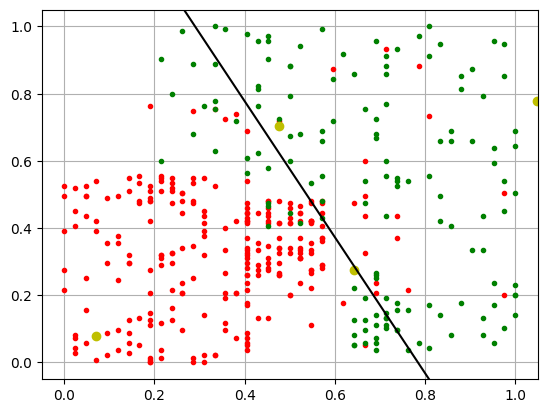

In [223]:
# Plot new data points
plot_Xy(Xn, y)
plt.plot(Xn_new[:, 0], Xn_new[:, 1], 'yo');
add_decision_boundary(lr)

## Make Blobs

In this exercise, we will create a dataset using the `make_blobs` function from the `sklearn.datasets` module.

Check the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) and create a dataset with 200 samples, 2 features, and 2 classes. The number of classes is determined by the number of `centers`. Set the random seed to 2025 using the `random_state` input parameter. Leave the other input arguments at their default values.

If everything goes well, you will get a dataset where the 2 classes are perfectly separable. Check this by creating a scatter plot. Note that you need to increase the `cluster_std` input argument when you want overlapping blobs.

Apply the perceptron algorithm and logistic regression. Do you actually get 100% accuracy in both cases? Create a scatter plot with the decision boundary of both models to visualize the result. Add a legend and a grid to your plot.

### Solution

In [225]:
# import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.datasets import make_blobs

In [236]:
# create dataset
X, y = make_blobs(n_samples=200,      # 200 samples
                  n_features=2,       # 2 features
                  centers=2,          # 2 classes
                  random_state=2025)  # set seed for random generator

print(X.shape)
print(y.shape)
print(np.unique(y))

(200, 2)
(200,)
[0 1]


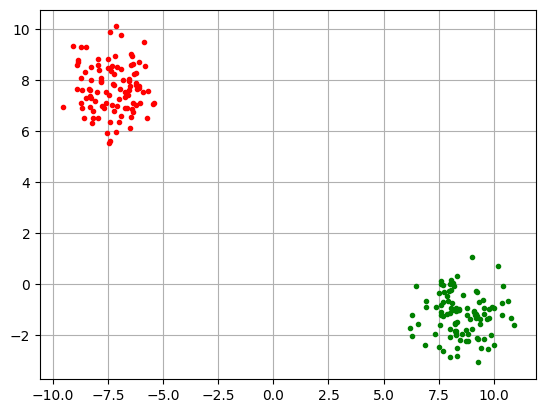

In [237]:
# check by plotting the data

def plot_Xy(X, y):
    plt.plot(X[y==0, 0], X[y==0, 1], 'r.');
    plt.plot(X[y==1, 0], X[y==1, 1], 'g.');
    plt.grid();

plot_Xy(X, y)

In [238]:
# perceptron
per = Perceptron()
per.fit(X, y)
per.score(X, y)  # accuracy

1.0

In [239]:
# logistic regression
lr = LogisticRegression(penalty=None)
lr.fit(X, y)
lr.score(X, y)  # accuracy

1.0

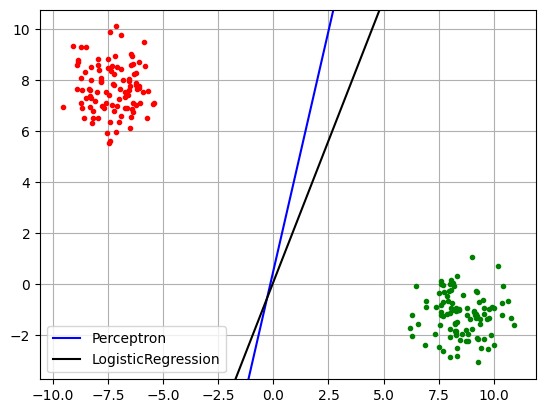

In [241]:
# plot decision boundaries

def add_decision_boundary(model, X, style):
    xmin, xmax = X[:, 0].min(), X[:, 0].max()
    xline = np.array((xmin, xmax))
    w, b = model.coef_[0], model.intercept_[0]
    yline = -xline * w[0] / w[1] - b / w[1]
    plt.plot(xline, yline, style, label=model.__class__.__name__);

plot_Xy(X, y)
xl, yl = plt.xlim(), plt.ylim()
add_decision_boundary(per, X, 'b-')
add_decision_boundary(lr, X, 'k-')
plt.xlim(xl)
plt.ylim(yl)
plt.legend();

## Titanic

In this exercise, you will work with a slightly more extensive dataset, namely the very famous Titanic dataset. To keep it manageable, you will receive a cleaned version of the dataset stored in the file `'titanic.csv'`. The goal is to predict whether someone survived the disaster based on various features.

You will need to discard two attributes from the dataset. Which ones and why? You will also need to encode some categorical variables. Use the DataFrame method `map()` for this. Finally, there is one feature that you should rescale by dividing by its maximum value.

Apply both perceptron and logistic regression, and search for the best hyperparameters. For perceptron, find the optimal learning rate, and for logistic regression, determine whether L2-regularization is needed. Because the models are linear, overfitting is likely not a problem —in fact, they are more likely to underfit— so it is not necessary to split the dataset here.

### Solution

In [287]:
# read dataset
df = pd.read_csv('titanic.csv')
df.head()

,passengerId,survived,pclass,sex,age,ticket,fare,embarked,title,deck,relatives,not_alone
0,1,0,3,male,22,A/5 21171,0,S,1,8,1,0
1,2,1,1,female,38,PC 17599,3,C,3,3,1,0
2,3,1,3,female,26,STON/O2. 3101282,0,S,2,8,0,1
3,4,1,1,female,35,113803,3,S,3,3,1,0
4,5,0,3,male,35,373450,1,S,1,8,0,1


In [288]:
# get dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   passengerId  891 non-null    int64 
 1   survived     891 non-null    int64 
 2   pclass       891 non-null    int64 
 3   sex          891 non-null    object
 4   age          891 non-null    int64 
 5   ticket       891 non-null    object
 6   fare         891 non-null    int64 
 7   embarked     891 non-null    object
 8   title        891 non-null    int64 
 9   deck         891 non-null    int64 
 10  relatives    891 non-null    int64 
 11  not_alone    891 non-null    int64 
dtypes: int64(9), object(3)
memory usage: 83.7+ KB


In [289]:
# calculate summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
passengerId,891.0,446.000000,257.353842,1.0,223.5,446.0,668.5,891.0
survived,891.0,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
age,891.0,29.460157,13.532870,0.0,21.0,28.0,38.0,80.0
fare,891.0,1.523008,1.250743,0.0,0.0,1.0,2.0,5.0
title,891.0,1.728395,1.030039,1.0,1.0,1.0,2.0,5.0
deck,891.0,6.936027,2.074282,0.0,8.0,8.0,8.0,8.0
relatives,891.0,0.904602,1.613459,0.0,0.0,0.0,1.0,10.0
not_alone,891.0,0.602694,0.489615,0.0,0.0,1.0,1.0,1.0


In [290]:
# check number of unique values in each column
for col in df.columns:
    print(f'{col}: {len(df[col].unique())}')

passengerId: 891
survived: 2
pclass: 3
sex: 2
age: 71
ticket: 681
fare: 6
embarked: 3
title: 5
deck: 9
relatives: 9
not_alone: 2


In [291]:
# drop passengerID and ticket
df.drop(['passengerId', 'ticket'], axis=1, inplace=True)

In [292]:
# print the unique values of each variable
for col in df.columns:
    print(f'{col}: {df[col].unique()}')

survived: [0 1]
pclass: [3 1 2]
sex: ['male' 'female']
age: [22 38 26 35 27 54  2 14  4 58 20 39 55 31 37 34 15 28  8 19 40 25 66 42
 29 21 18  3  7 49 65  5 11 45 17 32 16 43  0 30 33 23 24 46 59 71 47 70
 12  9 36 51 44  1 61 56 50 62 41 52 63 60 10 64 13 48 53 57 80  6 74]
fare: [0 3 1 2 5 4]
embarked: ['S' 'C' 'Q']
title: [1 3 2 4 5]
deck: [8 3 5 7 4 1 2 6 0]
relatives: [ 1  0  4  2  6  5  3  7 10]
not_alone: [0 1]


In [293]:
# encode features sex and embarked
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [280]:
# scale feature age
df['age'] /= 80  # max age is 80

In [295]:
# features X and label y
y = df['survived']
X = df.drop(['survived'], axis=1)

In [297]:
# Perceptron: loop over a range of learning rates
for eta0 in np.logspace(-6, 1, 8):
    print(f'Learning rate = {eta0}')
    per = Perceptron(eta0=eta0)
    per.fit(X, y)
    print(f'Accuracy = {per.score(X, y)}\n')

Learning rate = 1e-06
Accuracy = 0.792368125701459

Learning rate = 1e-05
Accuracy = 0.792368125701459

Learning rate = 0.0001
Accuracy = 0.5780022446689114

Learning rate = 0.001
Accuracy = 0.6891133557800224

Learning rate = 0.01
Accuracy = 0.7564534231200898

Learning rate = 0.1
Accuracy = 0.6038159371492705

Learning rate = 1.0
Accuracy = 0.7643097643097643

Learning rate = 10.0
Accuracy = 0.7643097643097643



In [306]:
# Logistic regression - check penalty
for penalty in [None, 'l2']:
    print(f'Penalty = {penalty}')
    lr = LogisticRegression(penalty=penalty, max_iter=1000)
    lr.fit(X, y)
    print(f'Accuracy = {lr.score(X, y)}\n')

Penalty = None
Accuracy = 0.813692480359147

Penalty = l2
Accuracy = 0.8125701459034792



In [304]:
# best model: logistic regression without penalty
best_model = LogisticRegression(penalty=None, max_iter=1000)
best_model.fit(X, y)
print(f'Accuracy = {best_model.score(X, y):.2%}')

Accuracy = 81.37%


---